In [5]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as grid

import statsmodels.api as sm
import statsmodels.formula.api as smf


tactics_bio = [
    "ouverture",
    "authenticité",
    "sociabilité",
    "auto_promotion",
    "exemplarité",
]

In [2]:
path_df=r"../data_processed\listings_tactics_bio_vis-paris_london-2306_2312_2406.csv"
df_all=pd.read_csv(path_df)
print(df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\4181052062.py:2: DtypeWarning: Columns (6,68,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv(path_df)


(266852, 125)


In [53]:
tactics_bio=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
tactic_pic=["host_picture_type"]# is_smiling
# vars_person=['age_class','gender']


df_all[tactics_bio]=df_all[tactics_bio].fillna(0)
df_all["host_picture_type"]=df_all["host_picture_type"].fillna("no_person")

print(df_all[tactics_bio].isna().value_counts())
print(df_all["host_picture_type"].isna().value_counts())

df_all['time']=df_all['time'].astype(str)
print(df_all.time.dtype)
print(df_all[['time','in_paris']].value_counts(dropna=False))


ouverture  authenticité  sociabilité  auto_promotion  exemplarité
False      False         False        False           False          266852
Name: count, dtype: int64
host_picture_type
False    266852
Name: count, dtype: int64
object
time  in_paris
2406  1           62738
      0           49856
2312  0           43172
2306  0           42356
2312  1           35829
2306  1           32901
Name: count, dtype: int64


## new & old

In [54]:
# df = df_all.copy()
host_2306 = df_all[df_all['time'] == "2306"]['host_id'].to_list()
host_2312 = df_all[df_all['time'] == "2312"]['host_id'].to_list()

# sub_df = df[df['time'] != '2306'].copy()

df_all['is_new_host'] = 0  # 先初始化

# 先选中mask避免覆盖
# 2312 vs 2306
mask_2312 = df_all['time'] == "2312"
df_all.loc[mask_2312, 'is_new_host'] = (
    ~df_all.loc[mask_2312, 'host_id'].isin(host_2306)
).astype(int)

# 2406 vs 2312
mask_2406 = df_all['time'] == "2406"
df_all.loc[mask_2406, 'is_new_host'] = (
    ~df_all.loc[mask_2406, 'host_id'].isin(host_2312)
).astype(int)

print(df_all[['time', 'is_new_host']].value_counts(dropna=False))



time  is_new_host
2306  0              75257
2406  0              72113
2312  0              57140
2406  1              40481
2312  1              21861
Name: count, dtype: int64


In [143]:
# sub_df['group_pn'] = sub_df.apply(
#     lambda x: f"{'paris' if x['in_paris']==1 else 'london'}_" +
#               f"{'new' if x['is_new_host']==1 else 'old'}",
#     axis=1
# )
# print(sub_df['group_pn'].value_counts(dropna=False))


In [56]:
df=df_all.copy()

df_2406=df[df['time']=="2406"]
print(df_2406.shape)
print(df_2406[['time', 'is_new_host']].value_counts())

df_2312=df[df['time']=="2406"]
print(df_2312.shape)
print(df_2312[['time', 'is_new_host']].value_counts())
print(df_2312['time'].dtype)

(112594, 126)
time  is_new_host
2406  0              72113
      1              40481
Name: count, dtype: int64
(112594, 126)
time  is_new_host
2406  0              72113
      1              40481
Name: count, dtype: int64
object


In [ ]:
display(df_2406.groupby(["in_paris", 'is_new_host'])[['booking_rate_l90d','years_since_host']].mean().reset_index())
df_2406.groupby(["in_paris", 'is_new_host'])['host_is_superhost'].value_counts()
display(df_2406.groupby(["in_paris", 'is_new_host'])['host_picture_type'].value_counts(normalize=True).reset_index())
# paris 2024显然更高比例的portrait
#

,in_paris,is_new_host,booking_rate_l90d,years_since_host
0,0,0,0.113584,6.708754
1,0,1,0.138104,5.397936
2,1,0,0.085889,7.061330
3,1,1,0.064405,6.567747


,in_paris,is_new_host,host_picture_type,proportion
0,0,0,no_person,0.383900
1,0,0,pro_style,0.322060
2,0,0,life_style,0.294040
3,0,1,pro_style,0.344828
4,0,1,no_person,0.339878
5,0,1,life_style,0.315295
6,1,0,no_person,0.380794
7,1,0,pro_style,0.347817
8,1,0,life_style,0.271389
9,1,1,pro_style,0.432358


In [ ]:
times=['2312', "2406"]
in_paris=[0]

df_t=df.copy()

df_t = df_t[df_t['time'].isin(times)]
df_t = df_t[df_t['in_paris'].isin(in_paris)]

print(df.shape, '=>', df_t.shape)
df_t[['time','in_paris']].value_counts()

(266852, 126) => (93028, 126)


time  in_paris
2406  0           49856
2312  0           43172
Name: count, dtype: int64

In [64]:
from scipy import stats

def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''
    
def ttest_new_old(df, times: list=["2312"], in_paris=[0, 1], vars=tactics_bio):
    # check time & in_paris
    df_t=df.copy()
        
    df_t = df_t[df_t['time'].isin(times)]
    df_t = df_t[df_t['in_paris'].isin(in_paris)]

    print(df.shape, '=>', df_t.shape)
    
    groups_in_paris=df_t['in_paris'].unique()
    groups_time=df_t['time'].unique()
    # print(groups_in_paris)
    
    rows=[]
    for time in groups_time:    
        for p in groups_in_paris:        
            for var in vars:
                sub = df_t[(df_t['time'] == time) & (df_t['in_paris'] == p)]# impo!!
                new = sub[sub['is_new_host'] == 1][var].dropna()
                old = sub[sub['is_new_host'] == 0][var].dropna()

                t_stat, p_value = stats.ttest_ind(new, old, equal_var=False)
                sig=p_to_sig(p_value)
                
                row_new= pd.DataFrame({
                    "time": [time],
                    "in_paris":[p],
                    "variable":var,
                    "t_stat": [t_stat],
                    "p_value": [p_value],
                    "sig":[sig],
                    'is_new_host':1,
                    'mean':[new.mean()],
                    'label':f"{var} {sig}"
                })
                
                row_old= pd.DataFrame({
                    "time": [time],
                    "in_paris":[p],
                    "variable":var,
                    "t_stat": [t_stat],
                    "p_value": [p_value],
                    "sig":[sig],
                    'is_new_host':0,
                    'mean':[old.mean()],
                    'label':f"{var} {sig}"
                })
                
                rows.append(row_new)
                rows.append(row_old)
    return pd.concat(rows, axis=0)


(266852, 126) => (112594, 126)


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\3439875818.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\3439875818.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\3439875818.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


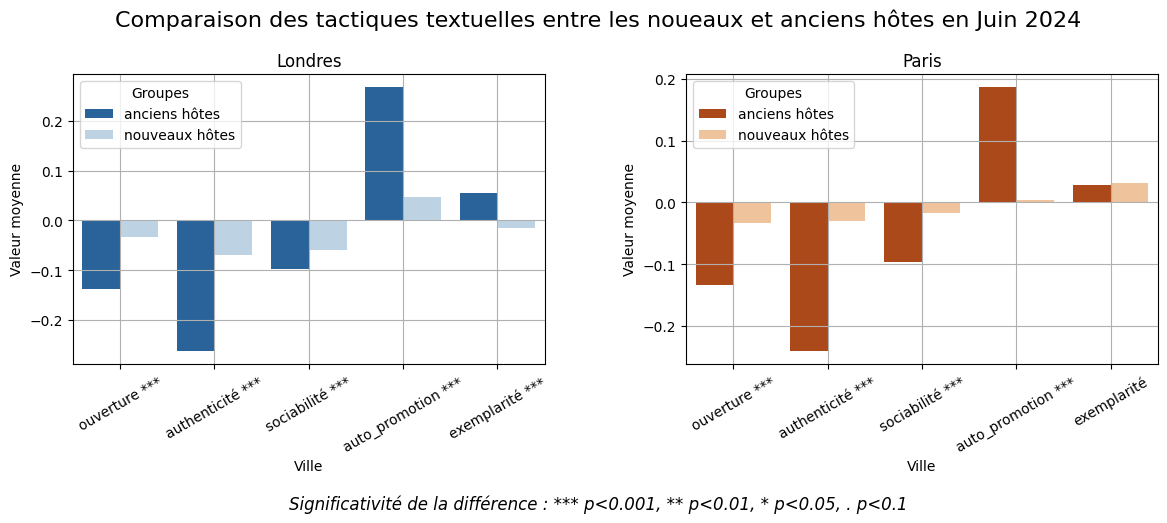

In [ ]:

## 2406 london + paris new vs old
import matplotlib.pyplot as plt
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]

# ---plot data---    
df_plot=ttest_new_old(df, times=["2406"], in_paris=[0,1], vars=order_tactics)


# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)


## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])


# ---plot---
for i, p in enumerate(df_plot['in_paris'].unique()):
    ax=axes[i]
    
    sub=df_plot[df_plot['in_paris']==p]
    if p==1:
        palette=dict(zip(sub['is_new_host'], paris_colors))
    else :
        palette=dict(zip(sub['is_new_host'], london_colors))
   
    sns.barplot(
        data=sub,   
        x='variable',
        y="mean",
        hue="is_new_host",
        palette=palette,
        order=order_tactics,
        ax=ax,
    )
    
   
    label_map = (
        sub[['variable', 'sig']]
        .drop_duplicates()
        .set_index('variable')['sig']
    )
    ax.set_xticklabels([
        f"{var} {label_map.get(var, '')}".strip()
        for var in order_tactics
    ])

    ax.set_xlabel("Ville")
    ax.set_ylabel("Valeur moyenne")
    ax.tick_params(axis="x",rotation=30)

    ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
    
    handles, labels = ax.get_legend_handles_labels()
    new_labels = ["anciens hôtes", "nouveaux hôtes"]
    ax.legend(handles, new_labels, title="Groupes")
    
    ax.grid()

## ---legend 2facets----
fig.suptitle(
        # "Effets marginaux des tactiques visuelles entre les groupes",
        "Comparaison des tactiques textuelles entre les noueaux et anciens hôtes en Juin 2024",
        fontsize=16,
        y=1.01
    )

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.3)#控制子图到底的距离，给text留出空间
plt.show()

# 新房东在前三显著水平更高，但在auto水平更低？exem无区别
# london的趋势相同
#****

(266852, 126) => (79001, 126)


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\2277360621.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\2277360621.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\2277360621.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


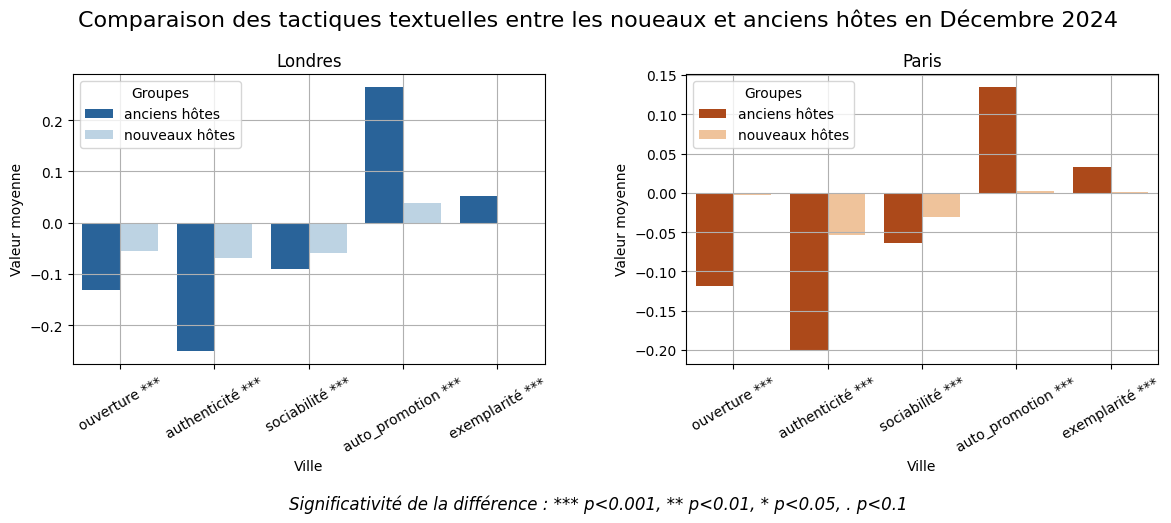

In [ ]:
## 2312 london + paris new vs old
import matplotlib.pyplot as plt

# ---plot data---
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
df_plot=ttest_new_old(df, times=["2312"], in_paris=[0,1], vars=order_tactics)

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])


# ---plot---
for i, p in enumerate(df_plot['in_paris'].unique()):
    ax=axes[i]
    
    sub=df_plot[df_plot['in_paris']==p]
    if p==1:
        palette=dict(zip(sub['is_new_host'], paris_colors))
    else :
        palette=dict(zip(sub['is_new_host'], london_colors))
   
    sns.barplot(
        data=sub,   # 用 df_long（不是 df_stats）
        x='variable',
        y="mean",
        hue="is_new_host",
        palette=palette,
        order=order_tactics,
        ax=ax,
        
    )
    
    label_map = (
        sub[['variable', 'sig']]
        .drop_duplicates()
        .set_index('variable')['sig']
    )

    ax.set_xticklabels([
        f"{var} {label_map.get(var, '')}".strip()
        for var in order_tactics
    ])

    ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
    ax.set_xlabel("Ville")
    ax.set_ylabel("Valeur moyenne")
    ax.tick_params(axis="x",rotation=30)
    handles, labels = ax.get_legend_handles_labels()
    new_labels = ["anciens hôtes", "nouveaux hôtes"]
    ax.legend(handles, new_labels, title="Groupes")
    ax.grid()

## ---legend 2facets----
fig.suptitle(
    "Comparaison des tactiques textuelles entre les noueaux et anciens hôtes en Décembre 2024",
    fontsize=16,
        y=1.01
    )

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.3)#控制子图到底的距离，给text留出空间
plt.show()

# 2312(类似于2406),在两地类似，前三增加，auto减少

In [69]:

## 2406 : london + paris superhost vs autres
# df['host_is_superhost']=df['host_is_superhost'].apply(lambda x : 1 if x=="t" else 0)
# print(df['host_is_superhost'].value_counts())

def ttest_superhost(df, times: list=["2012"], in_paris=[0, 1], vars=tactics_bio):
    # check time & in_paris
    df_t=df.copy()
    df_t['host_is_superhost']=df_t['host_is_superhost'].apply(lambda x : 1 if x=="t" else 0)
    df_t = df_t[df_t['time'].isin(times)]
    df_t = df_t[df_t['in_paris'].isin(in_paris)]

    print(df.shape, '=>', df_t.shape)
    
    groups_in_paris=df_t['in_paris'].unique()
    groups_time=df_t['time'].unique()
    # print(groups_in_paris)
    
    rows=[]
    for time in groups_time:    
        for p in groups_in_paris:        
            for var in vars:
                sub = df_t[(df_t['time'] == time) & (df_t['in_paris'] == p)]                
                super = sub[sub['host_is_superhost'] == 1][var].dropna()                
                host = sub[sub['host_is_superhost'] == 0][var].dropna()
                t_stat, p_value = stats.ttest_ind(super, host, equal_var=False)
                sig=p_to_sig(p_value)
                
                row_super= pd.DataFrame({
                    "time": [time],
                    "in_paris":[p],
                    "variable":var,
                    "t_stat": [t_stat],
                    "p_value": [p_value],
                    "sig":[sig],
                    'host_is_superhost':1,
                    'mean':[super.mean()],
                    'label':f"{var} {sig}"
                })
                
                row_host= pd.DataFrame({
                    "time": [time],
                    "in_paris":[p],
                    "variable":var,
                    "t_stat": [t_stat],
                    "p_value": [p_value],
                    "sig":[sig],
                    'host_is_superhost':0,
                    'mean':[host.mean()],
                    'label':f"{var} {sig}"
                })
                rows.append(row_super)
                rows.append(row_host)
    return pd.concat(rows, axis=0)


(266852, 126) => (112594, 126)


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\1368487043.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\1368487043.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\1368487043.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


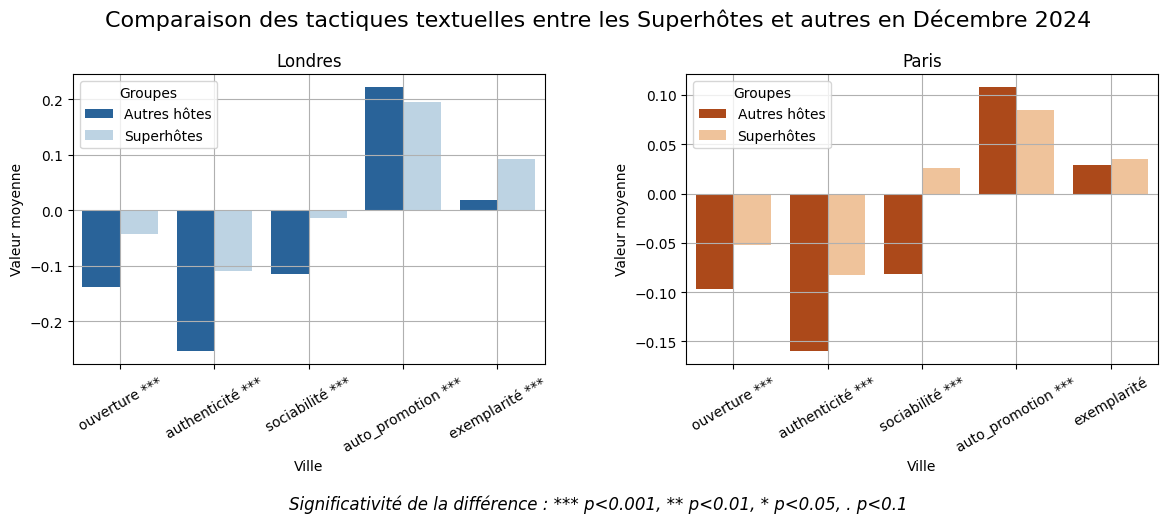

In [74]:
# 2406 : paris + london, superhost vs others:
# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])


# ---data---
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
df_plot=ttest_superhost(df, times=["2406"], in_paris=[0,1], vars=order_tactics)

# ---plot---

subplot_col='in_paris'
hue_col="host_is_superhost"

for i, p in enumerate(df_plot[subplot_col].unique()):#分图
    ax=axes[i]
    sub=df_plot[df_plot[subplot_col]==p]
    # display(sub)
    
    if p==1:
        palette=dict(zip(sub[hue_col].unique(), paris_colors))
    else :
        palette=dict(zip(sub[hue_col].unique(), london_colors))
   
    sns.barplot(
        data=sub,   
        x='variable',
        y="mean",
        hue=hue_col,
        palette=palette,
        order=order_tactics,
        ax=ax
    )   
    
    label_map = (
        sub[['variable', 'sig']]
        .drop_duplicates()
        .set_index('variable')['sig']
    )
    
    ax.set_xticklabels([
        f"{var} {label_map.get(var, '')}".strip()
        for var in order_tactics
    ])

    ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
    ax.set_xlabel("Ville")
    ax.set_ylabel("Valeur moyenne")
    ax.tick_params(axis="x",rotation=30)
    handles, labels = ax.get_legend_handles_labels()
    labels = ["Autres hôtes","Superhôtes"]
    ax.legend(handles, labels, title="Groupes")
    ax.grid()

## ---legend 2facets----
fig.suptitle(
    "Comparaison des tactiques textuelles entre les Superhôtes et autres en Décembre 2024",
    fontsize=16,
        y=1.01
    )

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.3)#控制子图到底的距离，给text留出空间
plt.show()

In [ ]:
# 2312 vs 2406
def ttest_by_time(df, times: list=["2012"], in_paris=[0, 1], is_new_host=[1], vars=tactics_bio):
    # ---data---
    df_t=df.copy()        
    df_t = df_t[df_t['time'].isin(times)]
    df_t = df_t[df_t['in_paris'].isin(in_paris)]
    df_t = df_t[df_t['is_new_host'].isin(is_new_host)]
    print(df.shape, '=>', df_t.shape)
    print(df_t[['is_new_host','time', "in_paris"]].value_counts(dropna=False))
    groups_in_paris=df_t['in_paris'].unique()
    groups_new_host=df_t['is_new_host'].unique()
    # print(groups_in_paris)
    
    rows=[]
    for new in groups_new_host: # 统一
        for p in groups_in_paris: #分图 
            for var in vars:
                sub = df_t[(df_t['is_new_host'] == new) & (df_t['in_paris'] == p)]                
                # hue
                early = sub[sub['time'] == "2312"][var].dropna()
                late = sub[sub['time'] == "2406"][var].dropna()
                
                t_stat, p_value = stats.ttest_ind(early, late, equal_var=False)
                sig=p_to_sig(p_value)
                
                row_early= pd.DataFrame({
                    "time": ["2312"],
                    "in_paris":[p],
                    "variable":var,
                    "t_stat": [t_stat],
                    "p_value": [p_value],
                    "sig":[sig],
                    'is_new_host':new,
                    'mean':[early.mean()],
                    'label':f"{var} {sig}"

                })
                row_late= pd.DataFrame({
                    "time": ["2406"],
                    "in_paris":[p],
                    "variable":var,
                    "t_stat": [t_stat],
                    "p_value": [p_value],
                    "sig":[sig],
                    'is_new_host':new,
                    'mean':[late.mean()],
                    'label':f"{var} {sig}"
                })
                rows.append(row_early)
                rows.append(row_late)
    return pd.concat(rows, axis=0)

(266852, 126) => (62342, 126)
is_new_host  time  in_paris
1            2406  1           28562
                   0           11919
             2312  1           11049
                   0           10812
Name: count, dtype: int64


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\817597268.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\817597268.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\817597268.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


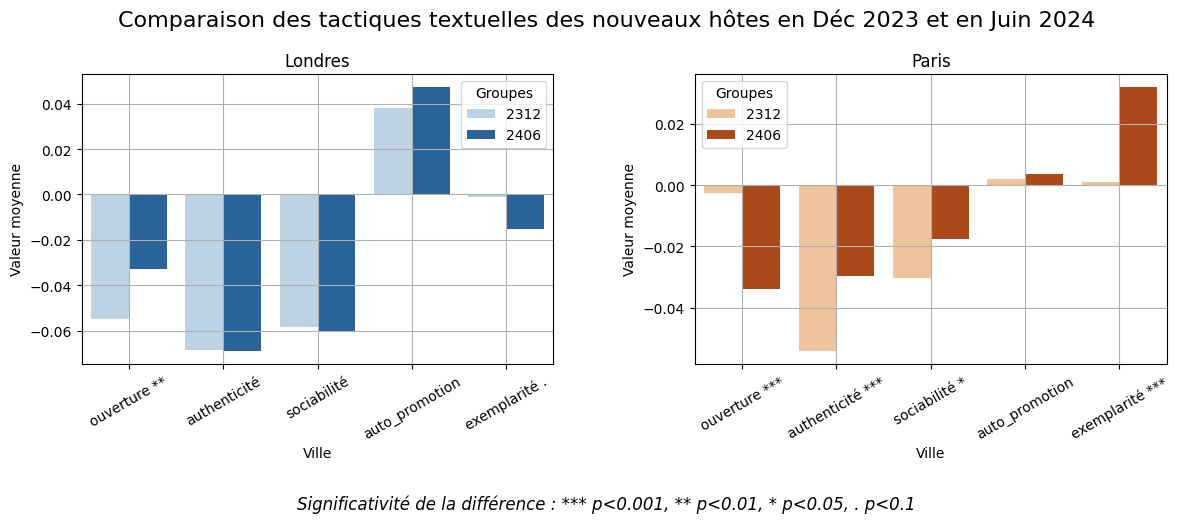

In [82]:
## NEW paris + london : 2312 vs 2406
# ---plot data---
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]

df_plot_new=ttest_by_time(df, times=["2312","2406"], in_paris=[0,1],is_new_host=[1], vars=order_tactics)


# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))
# #649BC8
colors = (
    list(london_colors) +
    list(paris_colors)
)

df_plot=df_plot_new.copy()
## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])

# ---plot---
for i, p in enumerate(df_plot['in_paris'].unique()):# ***分左右两图
    # print(p)
    ax=axes[i]
    
    sub=df_plot[df_plot['in_paris']==p]
    # display(sub)
    
    if p==1:# hue：分柱子的颜色
        palette=dict(zip(sub['time'].unique(), paris_colors))
    else :
        palette=dict(zip(sub['time'].unique(), london_colors))
        
    sns.barplot(
        data=sub, 
        x='variable',
        y="mean",
        hue="time",# hue
        palette=palette,
        order=order_tactics,
        ax=ax,        
    )
    
    label_map = (
        sub[['variable', 'sig']]
        .drop_duplicates()
        .set_index('variable')['sig']
    )
    ax.set_xticklabels([
        f"{var} {label_map.get(var, '')}".strip()
        for var in order_tactics
    ])

    ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
    ax.set_xlabel("Ville")
    ax.set_ylabel("Valeur moyenne")
    ax.tick_params(axis="x",rotation=30)
    # legend的分组
    handles, labels = ax.get_legend_handles_labels()
    # labels = ["Dec 2023", ""]
    ax.legend(handles, labels, title="Groupes")
    ax.grid()

## ---legend 2facets----
fig.suptitle(
    "Comparaison des tactiques textuelles des nouveaux hôtes en Déc 2023 et en Juin 2024",
    fontsize=16,
    y=1.01
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.3)#控制子图到底的距离，给text留出空间
plt.show()


#从2312到2406，paris新房东更多使用auth, socio, exem，但是ouv和auto更少
# 但london的新房东没有呈现相同的趋势!!!jo刺激了新房东


In [100]:
sub

,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,1,ouverture,5.533963,3.166305e-08,***,1,-0.002521,ouverture ***
0,2406,1,ouverture,5.533963,3.166305e-08,***,1,-0.034036,ouverture ***
0,2312,1,authenticité,-4.029937,5.599858e-05,***,1,-0.054085,authenticité ***
0,2406,1,authenticité,-4.029937,5.599858e-05,***,1,-0.029554,authenticité ***
0,2312,1,sociabilité,-2.129152,3.325350e-02,*,1,-0.030222,sociabilité *
0,2406,1,sociabilité,-2.129152,3.325350e-02,*,1,-0.017548,sociabilité *
0,2312,1,auto_promotion,-0.241920,8.088449e-01,,1,0.002145,auto_promotion
0,2406,1,auto_promotion,-0.241920,8.088449e-01,,1,0.003604,auto_promotion
0,2312,1,exemplarité,-4.898418,9.723848e-07,***,1,0.001056,exemplarité ***
0,2406,1,exemplarité,-4.898418,9.723848e-07,***,1,0.031944,exemplarité ***


(266852, 126) => (62342, 126)
is_new_host  time  in_paris
1            2406  1           28562
                   0           11919
             2312  1           11049
                   0           10812
Name: count, dtype: int64


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,0,ouverture,-2.769081,0.005626,**,1,-0.054907,ouverture **
0,2406,0,ouverture,-2.769081,0.005626,**,1,-0.032854,ouverture **
0,2312,0,authenticité,0.048290,0.961486,,1,-0.068509,authenticité
0,2406,0,authenticité,0.048290,0.961486,,1,-0.068915,authenticité
0,2312,0,sociabilité,0.249636,0.802871,,1,-0.058570,sociabilité
0,2406,0,sociabilité,0.249636,0.802871,,1,-0.060629,sociabilité
0,2312,0,auto_promotion,-1.081306,0.279572,,1,0.038115,auto_promotion
0,2406,0,auto_promotion,-1.081306,0.279572,,1,0.047285,auto_promotion
0,2312,0,exemplarité,1.834206,0.066637,.,1,-0.001066,exemplarité .
0,2406,0,exemplarité,1.834206,0.066637,.,1,-0.015097,exemplarité .


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,1,ouverture,5.533963,3.166305e-08,***,1,-0.002521,ouverture ***
0,2406,1,ouverture,5.533963,3.166305e-08,***,1,-0.034036,ouverture ***
0,2312,1,authenticité,-4.029937,5.599858e-05,***,1,-0.054085,authenticité ***
0,2406,1,authenticité,-4.029937,5.599858e-05,***,1,-0.029554,authenticité ***
0,2312,1,sociabilité,-2.129152,3.325350e-02,*,1,-0.030222,sociabilité *
0,2406,1,sociabilité,-2.129152,3.325350e-02,*,1,-0.017548,sociabilité *
0,2312,1,auto_promotion,-0.241920,8.088449e-01,,1,0.002145,auto_promotion
0,2406,1,auto_promotion,-0.241920,8.088449e-01,,1,0.003604,auto_promotion
0,2312,1,exemplarité,-4.898418,9.723848e-07,***,1,0.001056,exemplarité ***
0,2406,1,exemplarité,-4.898418,9.723848e-07,***,1,0.031944,exemplarité ***


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\4164017353.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


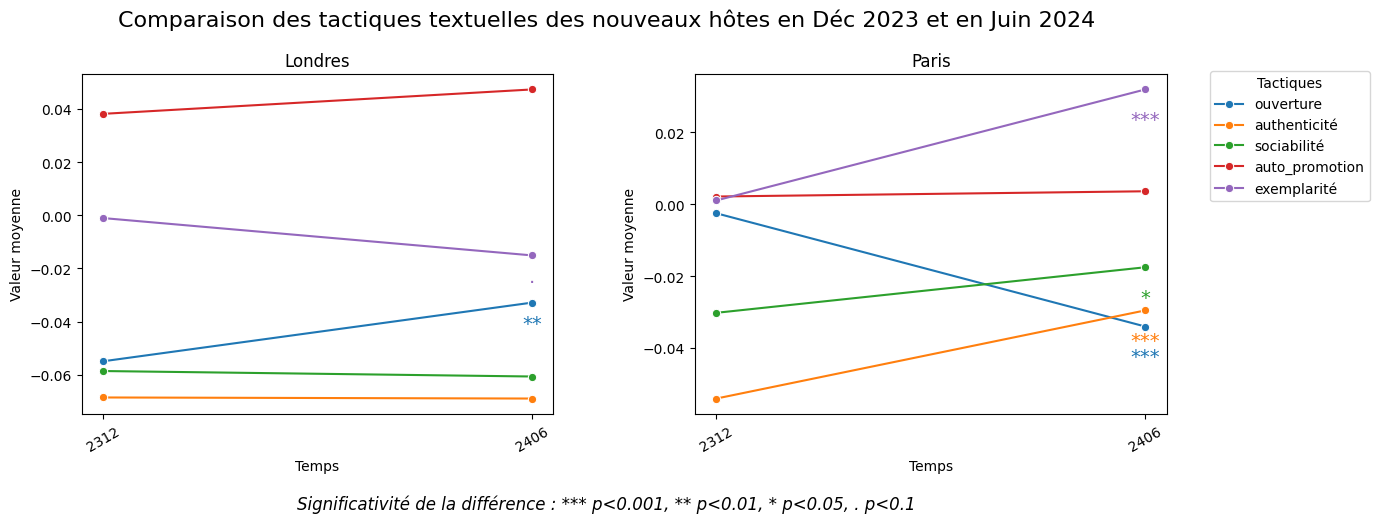

In [125]:
## NEW paris + london : 2312 vs 2406 [LINEPLOT]

# # ---colors----
palette = {
    "ouverture": "#1f77b4",
    "authenticité": "#ff7f0e",
    "sociabilité": "#2ca02c",
    "auto_promotion": "#d62728",
    "exemplarité": "#9467bd"
}


## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])


# ---plot data---
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
df_plot=ttest_by_time(df, times=["2312","2406"], in_paris=[0,1],is_new_host=[1], vars=order_tactics)


# ---plot---
for i, p in enumerate(df_plot['in_paris'].unique()):# ***分左右两图
    # print(p)
    ax=axes[i]
    
    sub=df_plot[df_plot['in_paris']==p]
    display(sub)
    
    x=list(range(len(sub['time'])))
    # print('axis x :', x)
        
    sns.lineplot(
        data=sub, 
        x='time',
        # x=x,
        y="mean",
        hue="variable",# hue
        marker='o',
        linestyle="-",
        palette=palette,
        # order=order_tactics,
        ax=ax,        
    )
    sub_sig=sub[sub['time']=="2406"]
    # display(sub_sig)
    for _, row in sub_sig.iterrows():
        ax.text(row['time'], row["mean"] - 0.01, row["sig"],
                ha='center', fontsize=14, color=palette[row['variable']])

    ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
    ax.set_xlabel("Temps")
    ax.set_ylabel("Valeur moyenne")
    ax.tick_params(axis="x",rotation=30)
    
    if ax.legend():
        ax.get_legend().remove()
    

## ---legend 2facets----
fig.suptitle(
    "Comparaison des tactiques textuelles des nouveaux hôtes en Déc 2023 et en Juin 2024",
    fontsize=16,
    y=1.01
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Tactiques", loc="upper right", bbox_to_anchor=(1.05, 0.9))

plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()



(266852, 126) => (129253, 126)
is_new_host  time  in_paris
0            2406  0           37937
                   1           34176
             2312  0           32360
                   1           24780
Name: count, dtype: int64


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\4235222070.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\4235222070.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\4235222070.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


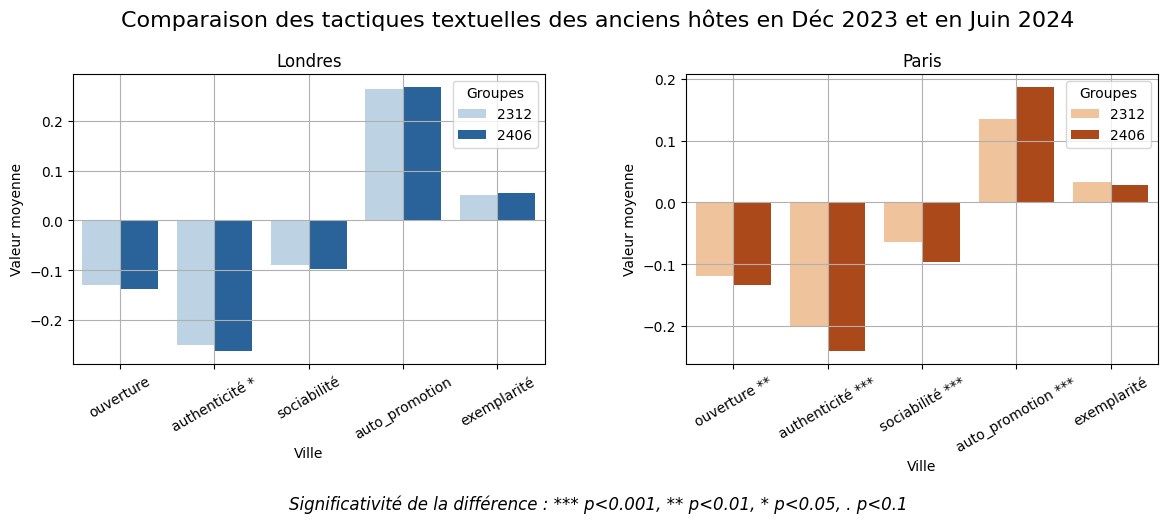

In [ ]:
## OLD paris + london : 2312 vs 2406
# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))
# #649BC8
colors = (
    list(london_colors) +
    list(paris_colors)
)

df_plot=df_plot_new.copy()
## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])

# ---plot data---
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]

df_plot=ttest_by_time(df, times=["2312","2406"], in_paris=[0,1],is_new_host=[0], vars=order_tactics)


# ---plot---
for i, p in enumerate(df_plot['in_paris'].unique()):# ***分左右两图
    # print(p)
    ax=axes[i]
    
    sub=df_plot[df_plot['in_paris']==p]
    # display(sub)
    
    if p==1:# hue：分柱子的颜色
        palette=dict(zip(sub['time'].unique(), paris_colors))
    else :
        palette=dict(zip(sub['time'].unique(), london_colors))
        
    sns.barplot(
        data=sub, 
        x='variable',
        y="mean",
        hue="time",# hue
        palette=palette,
        order=order_tactics,
        ax=ax,        
    )
    
    label_map = (
        sub[['variable', 'sig']]
        .drop_duplicates()
        .set_index('variable')['sig']
    )
    ax.set_xticklabels([
        f"{var} {label_map.get(var, '')}".strip()
        for var in order_tactics
    ])

    ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
    ax.set_xlabel("Ville")
    ax.set_ylabel("Valeur moyenne")
    ax.tick_params(axis="x",rotation=30)
    # legend的分组
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title="Groupes")
    ax.grid()

## ---legend 2facets----
fig.suptitle(
    "Comparaison des tactiques textuelles des anciens hôtes en Déc 2023 et en Juin 2024",
    fontsize=16,
    y=1.01
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.3)#控制子图到底的距离，给text留出空间
plt.show()

In [60]:
#老房东是否更加积极地调整他们的策略？？
## PARIS : new + old, 2312 vs 2406
df=df_all.copy()
print(df.shape)

df_plot_paris=ttest_new_old(df, times=["2312","2406"], in_paris=[1], vars=tactics_bio)
df_plot_paris=df_plot_paris.sort_values(['is_new_host', "time"])
df_plot_paris

(266852, 126)
(266852, 126) => (98567, 126)


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,1,ouverture,26.739822,6.158085e-157,***,0,-0.127460,ouverture ***
0,2312,1,authenticité,46.582130,0.000000e+00,***,0,-0.223867,authenticité ***
0,2312,1,sociabilité,15.765053,6.359783e-56,***,0,-0.082801,sociabilité ***
0,2312,1,auto_promotion,-40.840682,0.000000e+00,***,0,0.164609,auto_promotion ***
0,2312,1,exemplarité,-1.690751,9.088786e-02,.,0,0.030357,exemplarité .
0,2406,1,ouverture,26.739822,6.158085e-157,***,0,-0.127460,ouverture ***
0,2406,1,authenticité,46.582130,0.000000e+00,***,0,-0.223867,authenticité ***
0,2406,1,sociabilité,15.765053,6.359783e-56,***,0,-0.082801,sociabilité ***
0,2406,1,auto_promotion,-40.840682,0.000000e+00,***,0,0.164609,auto_promotion ***
0,2406,1,exemplarité,-1.690751,9.088786e-02,.,0,0.030357,exemplarité .


is_new_host=1


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,1,ouverture,26.739822,6.158085e-157,***,1,-0.025245,ouverture ***
0,2312,1,authenticité,46.582130,0.000000e+00,***,1,-0.036397,authenticité ***
0,2312,1,sociabilité,15.765053,6.359783e-56,***,1,-0.021083,sociabilité ***
0,2312,1,auto_promotion,-40.840682,0.000000e+00,***,1,0.003197,auto_promotion ***
0,2312,1,exemplarité,-1.690751,9.088786e-02,.,1,0.023328,exemplarité .
0,2406,1,ouverture,26.739822,6.158085e-157,***,1,-0.025245,ouverture ***
0,2406,1,authenticité,46.582130,0.000000e+00,***,1,-0.036397,authenticité ***
0,2406,1,sociabilité,15.765053,6.359783e-56,***,1,-0.021083,sociabilité ***
0,2406,1,auto_promotion,-40.840682,0.000000e+00,***,1,0.003197,auto_promotion ***
0,2406,1,exemplarité,-1.690751,9.088786e-02,.,1,0.023328,exemplarité .


is_new_host=0


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\2497046819.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,1,ouverture,26.739822,6.158085e-157,***,0,-0.127460,ouverture ***
0,2312,1,authenticité,46.582130,0.000000e+00,***,0,-0.223867,authenticité ***
0,2312,1,sociabilité,15.765053,6.359783e-56,***,0,-0.082801,sociabilité ***
0,2312,1,auto_promotion,-40.840682,0.000000e+00,***,0,0.164609,auto_promotion ***
0,2312,1,exemplarité,-1.690751,9.088786e-02,.,0,0.030357,exemplarité .
0,2406,1,ouverture,26.739822,6.158085e-157,***,0,-0.127460,ouverture ***
0,2406,1,authenticité,46.582130,0.000000e+00,***,0,-0.223867,authenticité ***
0,2406,1,sociabilité,15.765053,6.359783e-56,***,0,-0.082801,sociabilité ***
0,2406,1,auto_promotion,-40.840682,0.000000e+00,***,0,0.164609,auto_promotion ***
0,2406,1,exemplarité,-1.690751,9.088786e-02,.,0,0.030357,exemplarité .


C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\2497046819.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_27036\2497046819.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


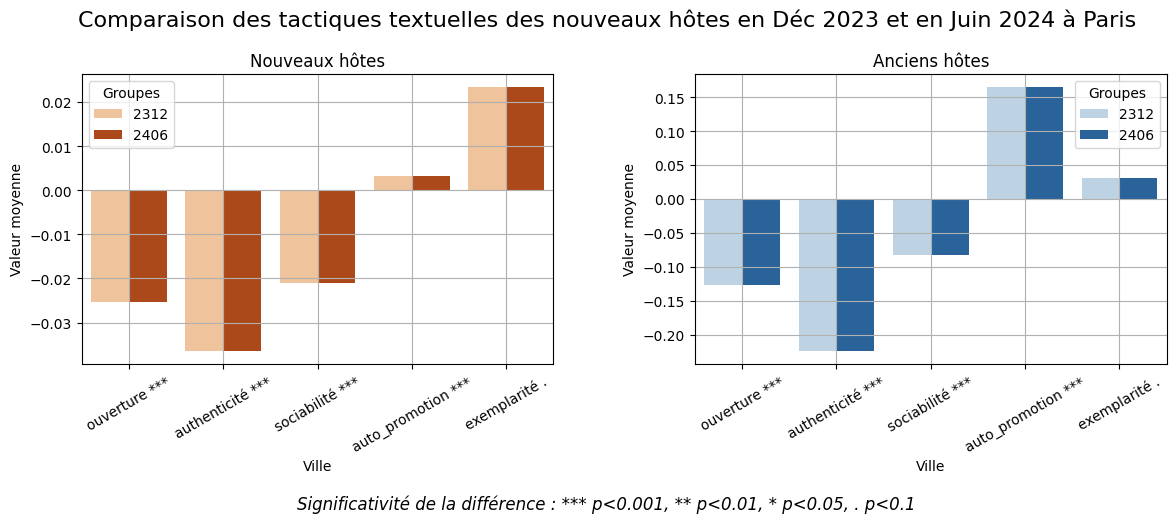

In [58]:
## PARIS : new + old, 2312 vs 2406
import matplotlib.pyplot as plt


order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])


# ---plot---
df_plot=df_plot_paris.copy()#***
subplot_col="is_new_host"
hue_col="time"

for i, sub_g in enumerate(df_plot[subplot_col].unique()):
    ax=axes[i]
    sub=df_plot[df_plot[subplot_col]==sub_g]
    print(f"{subplot_col}={sub_g}")
    display(sub)
    if sub_g==1:
        palette=dict(zip(sub[hue_col].unique(), paris_colors))
    else :
        palette=dict(zip(sub[hue_col].unique(), london_colors))
   
    sns.barplot(
        data=sub,   
        x='variable',
        y="mean",
        hue=hue_col,
        palette=palette,
        order=order_tactics,
        ax=ax,
    )

    label_map = (
        sub[['variable', 'sig']]
        .drop_duplicates()
        .set_index('variable')['sig']
    )
    ax.set_xticklabels([
        f"{var} {label_map.get(var, '')}".strip()
        for var in order_tactics
    ])

    ax.set_xlabel("Ville")
    ax.set_ylabel("Valeur moyenne")
    ax.tick_params(axis="x",rotation=30)

    ax.set_title(f"{'Nouveaux hôtes' if sub_g==1 else 'Anciens hôtes'}")
    
    handles, labels = ax.get_legend_handles_labels()
    # labels = ["anciens hôtes", "nouveaux hôtes"]
    ax.legend(handles, labels, title="Groupes")
    ax.grid()


## ---legend 2facets----
fig.suptitle(
        # "Effets marginaux des tactiques visuelles entre les groupes",
        "Comparaison des tactiques textuelles des nouveaux hôtes en Déc 2023 et en Juin 2024 à Paris",
        fontsize=16,
        y=1.01
    )

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.3)#控制子图到底的距离，给text留出空间
plt.show()



group
nouveaux hôtes(Londres)    5
anciens hôtes(Londres)     5
nouveaux hôtes(Paris)      5
anciens hôtes(Paris)       5
Name: count, dtype: int64


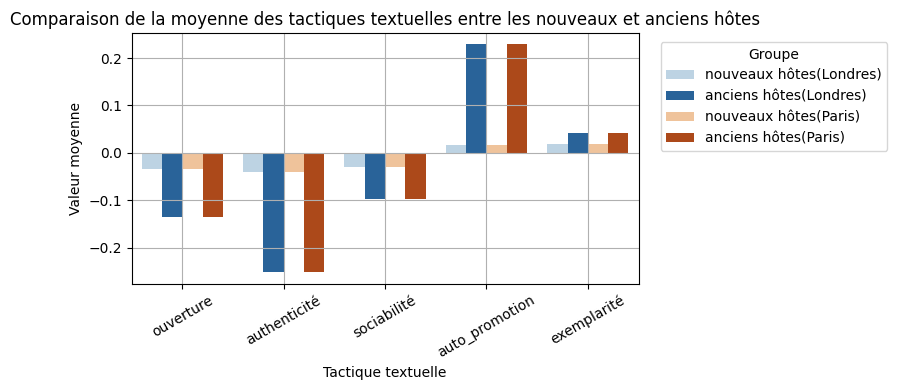

In [88]:
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
df_plot['group'] = df_plot.apply(
    lambda x: f"{'nouveaux hôtes' if x['is_new_host']==1 else 'anciens hôtes'}"
        f"{'(Paris)' if x['in_paris']==1 else '(Londres)'}"
    ,axis=1
)
print(df_plot['group'].value_counts(dropna=False))

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)

groups=df_plot['group'].unique()
palette={k: v for k, v in zip (groups, colors)}



fig, ax=plt.subplots(figsize=(6,4))

sns.barplot(
    data=df_plot,   # 用 df_long（不是 df_stats）
    x="variable",
    y="mean",
    hue="group",
    palette=palette,
    order=order_tactics,
    # errorbar="sd",
    ax=ax
)


ax.set_title("Comparaison de la moyenne des tactiques textuelles entre les nouveaux et anciens hôtes")
ax.set_xlabel("Tactique textuelle")
ax.set_ylabel("Valeur moyenne")
ax.tick_params(axis="x",rotation=30)
ax.get_legend().remove()

handles, labels=ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Groupe",  loc="upper left", bbox_to_anchor=(1, 0.9))
ax.grid()
plt.tight_layout(rect=[0, 0, 1, 1])


ouverture
authenticité
sociabilité
auto_promotion
exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_26240\2060331927.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0, 0.9,1])


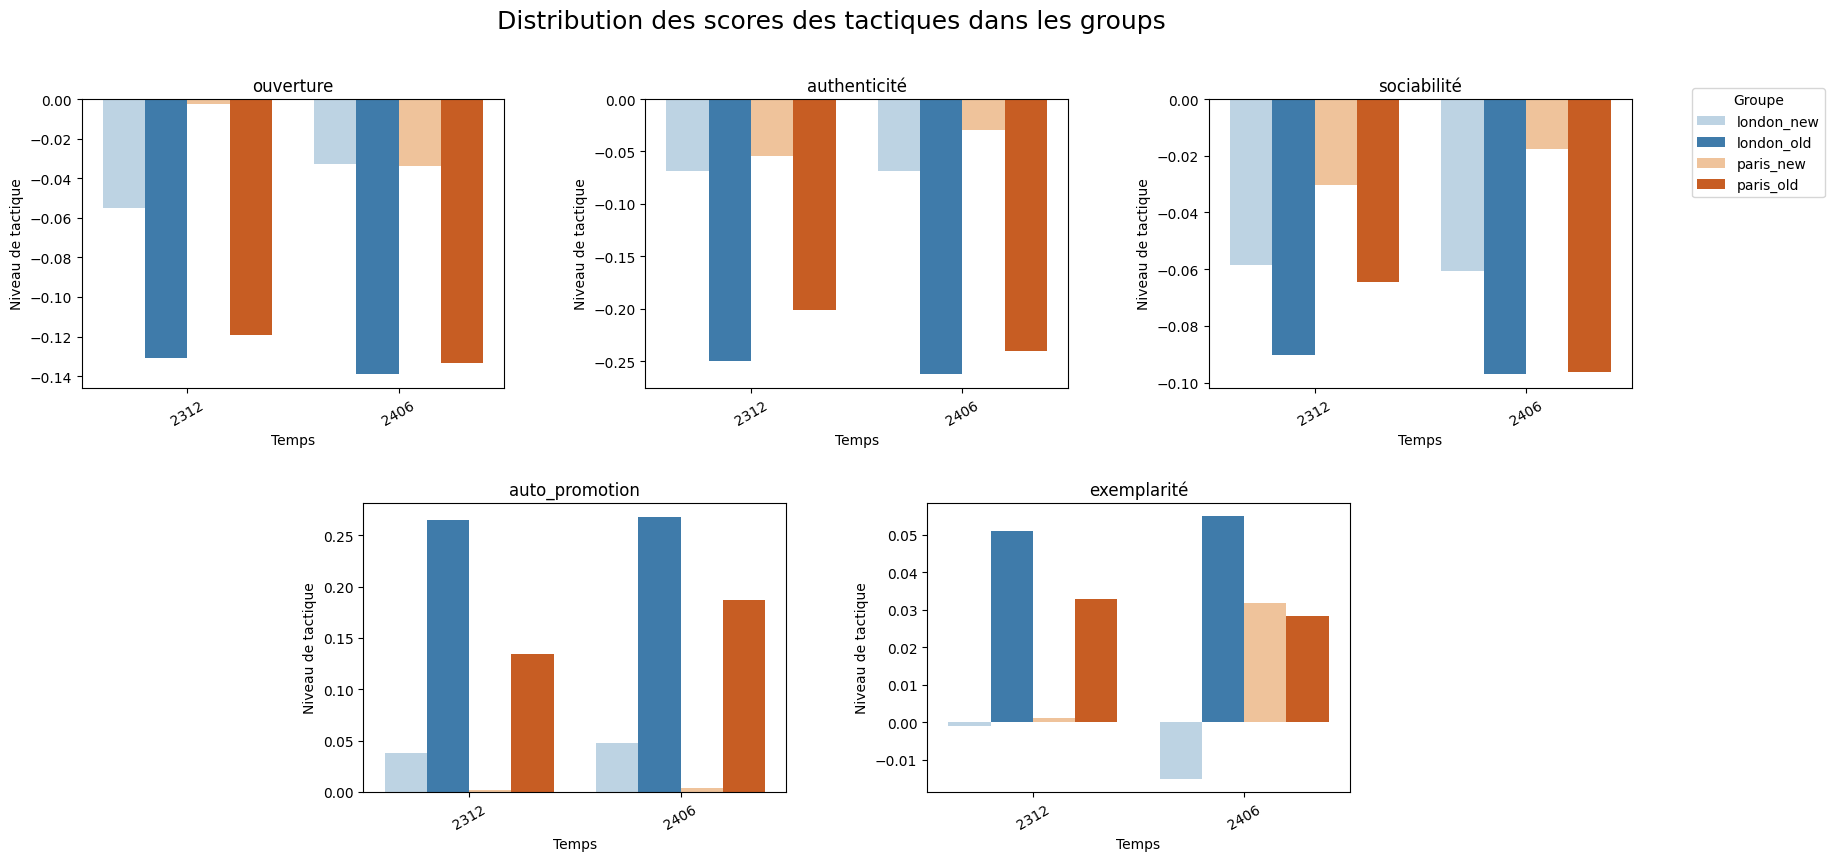

In [42]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

## ---subplot layout---
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)
axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# ---data---
# var="authenticité"
# agg=df_plot.groupby(["time","group_pn",'is_new_host'])[var].mean().reset_index()
# agg.rename(columns={f"{var}":"value"}, inplace=True)
# print(agg)


# ---colors----
blue_cmap=plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.7, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.7, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)
# groups=df_plot['group_pn'].unique()
# palette={k: v for k, v in zip (groups, colors)}


# ---plot---
# df_plot=sub_df.copy()
for i, var in enumerate(tactics_bio):
    print(var)
    ax=axes[i]
    agg=df_plot.groupby(["time","group_pn",'is_new_host'])[var].mean().reset_index()
    agg.rename(columns={f"{var}":"value"}, inplace=True)

    sns.barplot(
        data=agg,
        x='time',
        y="value",
        hue="group_pn",
        # palette=palette,
        ax=ax
    )
    ax.set_title(var)
    ax.set_xlabel("Temps")
    ax.set_ylabel("Niveau de tactique")
    ax.tick_params(axis="x", rotation=30)
    ax.get_legend().remove()
    
    
fig.suptitle(
        "Distribution des scores des tactiques dans les groups",
        fontsize=18,
        y=0.98
    )
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Groupe", loc="upper right", bbox_to_anchor=(1, 0.9))
plt.tight_layout(rect=[0,0, 0.9,1])
plt.show()
    
    



In [ ]:
import matplotlib.gridspec as gridspec


## ---subplot layout---
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)
axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])


# ---colors---
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 3  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)
# palette={k: v for k, v in zip (groups, colors)}



In [ ]:
# exemple de 2406
df_2406=df[df['time']==2406]
print(df_2406.shape)
print(df_2406[['time','in_paris','new_in_2406']].value_counts(dropna=False))


(112594, 127)
time  in_paris  new_in_2406
2406  0         0              37937
      1         0              34176
                1              28562
      0         1              11919
Name: count, dtype: int64


In [32]:
from utils import preprocess_listings
importlib.reload(preprocess_listings)
from utils.preprocess_listings import group_mean_table_ttest
 
tactics_bio = [
    "ouverture",
    "authenticité",
    "sociabilité",
    "auto_promotion",
    "exemplarité",
]
tactic_pic= [
    "host_picture_type",
    "is_smiling"
]

#  --- num---
vars_ctrl_num=[
    'booking_rate_l90d',
    "review_scores_rating", "has_rating", "number_of_reviews_ltm",
    'professional_host',
    "host_response_rate",
    "price","availability_90", 
    "years_since_host",
    "text_length",
]

# ---cat---
vars_ctrl_cat=[
    # cat
    "host_identity_verified",
    'host_is_superhost',
    'host_response_time',
    'room_type',"instant_bookable",    
    "has_text", "lang_en","lang_fr",    
    # "age_class","gender",
]


##
df_stats=df_2406.copy()
cols_to_check=vars_ctrl_num +tactics_bio

group_mean_table_ttest(df_stats, cols_to_check, group_col='new_in_2406',        
                    save=False, output_folder="mod_results", filename_noext=None)

#新进入，但不是有经验的房东



NameError: name 'df_2406' is not defined

In [71]:
agg=df_2406.groupby(['in_paris', 'new_in_2406'])[tactics_bio].mean().reset_index()
display(agg)

agg_long=agg.melt(
    id_vars=['in_paris','new_in_2406'],
    value_vars=tactics_bio,
    var_name='variable',
    value_name='value'
)
agg_long

,in_paris,new_in_2406,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,0,0,-0.138921,-0.262354,-0.096956,0.267661,0.054928
1,0,1,-0.032854,-0.068915,-0.060629,0.047285,-0.015097
2,1,0,-0.133475,-0.240384,-0.096182,0.186465,0.028441
3,1,1,-0.034036,-0.029554,-0.017548,0.003604,0.031944


,in_paris,new_in_2406,variable,value
0,0,0,ouverture,-0.138921
1,0,1,ouverture,-0.032854
2,1,0,ouverture,-0.133475
3,1,1,ouverture,-0.034036
4,0,0,authenticité,-0.262354
5,0,1,authenticité,-0.068915
6,1,0,authenticité,-0.240384
7,1,1,authenticité,-0.029554
8,0,0,sociabilité,-0.096956
9,0,1,sociabilité,-0.060629


In [94]:
sub=agg_long[agg_long['variable']=='authenticité']
sub

,in_paris,new_in_2406,variable,value
4,0,0,authenticité,-0.262354
5,0,1,authenticité,-0.068915
6,1,0,authenticité,-0.240384
7,1,1,authenticité,-0.029554


Text(0.5, 1.0, 'authenticité')

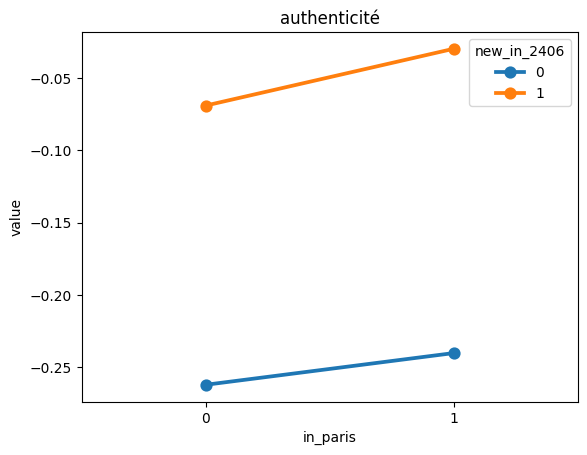

In [97]:
sns.pointplot(
    data=sub,
    x="in_paris",
    y="value",
    hue="new_in_2406",
    errorbar=("ci", 95),
)
plt.title('authenticité')


<Axes: xlabel='in_paris', ylabel='value'>

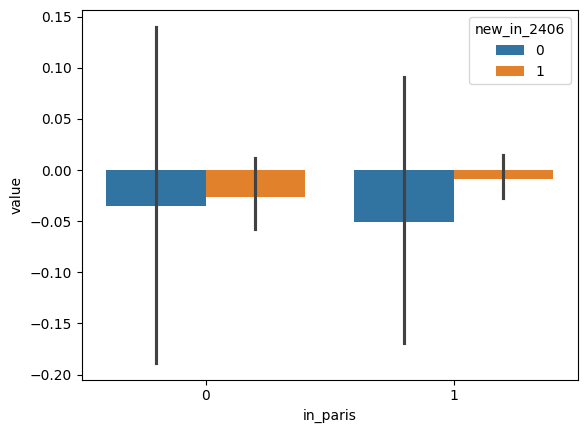

In [ ]:

sns.barplot(
    data=agg_long,
    x="in_paris",
    y="value",
    hue="new_in_2406",
)
plt.xlabel()

0 ouverture


,in_paris,new_in_2406,variable,value
0,0,0,ouverture,-0.138921
1,0,1,ouverture,-0.032854
2,1,0,ouverture,-0.133475
3,1,1,ouverture,-0.034036


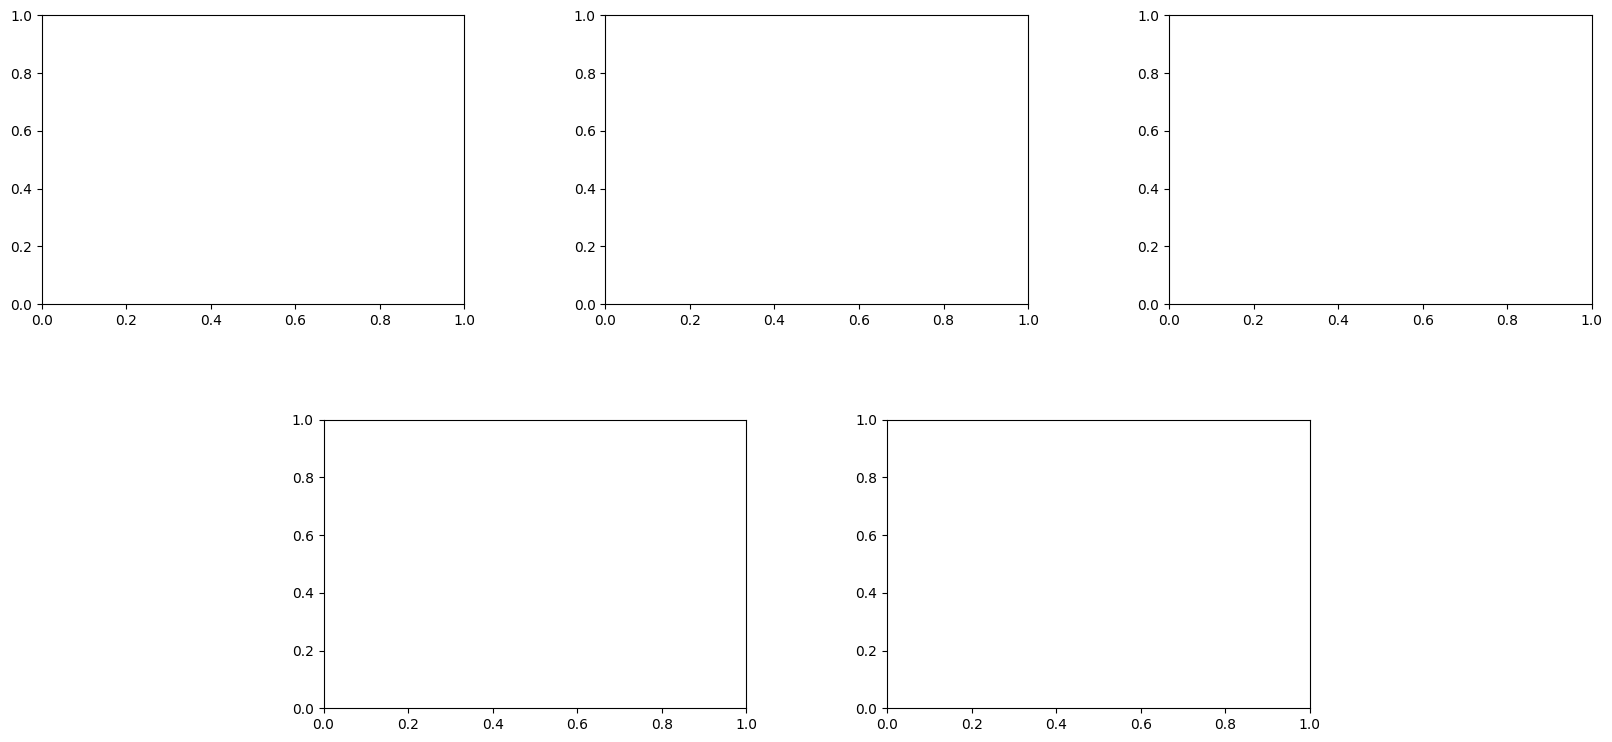

In [83]:
import matplotlib.gridspec as gridspec


# -------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


df_plot=agg_long.copy()

for i, var in enumerate(tactics_bio):
    print(i, var)
    sub=df_plot[df_plot['variable']==var]
    display(sub)
    
    # ax.plot(
    #     sub['']
    # )
    # sns.barplot(
    #     data=agg_long,
    #     x="in_paris",
    #     y="value",
    #     hue="new_in_2406",
    #     ax=axes[i],
    #     label=f"{'nouveaux entrant' if new_in_2406==1 else 0}"
    # )
    # axes[i].legend().remove()
    break


# handles,labels=axes[0].get_legend_handels_labels()

# sns.catplot(
#     data=agg_long,
#     kind="bar",
#     x="in_paris",
#     y="value",
#     hue="new_in_2406",
#     col="variable",
#     ax=ax,
#     # palette=["tab:blue","tab:orange"]
#     palette=[london_colors[2], paris_colors[2]]
# )